In [1]:
import pandas as pd
import pycaret
import sys
print(sys.version)

3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]


In [2]:
import pycaret.classification as pc_class
import pycaret.regression as pc_reg

## 1. Estudio previo - seleccion de target 

Nuestras variables predictoras son las que tenemos en el archivo 'caracteristicas_edificios.csv'. Antes de liarnos con el proyecto, vamos a ver qué resultados nos arroja un autoML, primero, para ver la pena si vale seguir o no, y segundo, para valorar sobre que target vamos a trabajar. Probaremos estos 4:

-Clasificación:

    -clase emisiones
    -clase consumo

-Regresión:

    -emisiones globales
    -consumos globales

## 2. Carga y preparacion de datos

In [3]:
caract = pd.read_csv('../data/clean/pre_clean/caracteristicas_edificios.csv')
demandas = pd.read_csv('../data/clean/pre_clean/demandas_energeticas.csv')
consumos = pd.read_csv('../data/clean/pre_clean/consumos_energeticos.csv')
emisiones = pd.read_csv('../data/clean/pre_clean/emisiones_ambientales.csv')
clases_edificios = pd.read_csv('../data/clean/pre_clean/clases_edificios.csv')

In [4]:
regresion_emisiones = pd.merge(caract, emisiones, how='inner', on='id_edificio')
regresion_emisiones.head()

,id_edificio,municipio,cp,provincia,zona_climatica,ano_construccion,normativa,tipo_edificio,superficie,compacidad,emisiones_global,emisiones_calefaccion,emisiones_refrigeracion
0,0,El Ejido,04711,Almería,A4,1979.0,Anterior,ViviendaIndividualEnBloque,37.07,2.46,21.30,10.17,5.10
1,1,El Ejido,04711,Almería,A4,1992.0,NBE-CT-79,ViviendaIndividualEnBloque,123.58,1.43,34.47,22.65,4.63
2,2,El Ejido,04700,Almería,A4,2003.0,NBE-CT-79,LocalUsoTerciario,104.25,1.79,19.35,9.20,3.27
3,3,El Ejido,04711,Almería,A4,1975.0,Anterior,ViviendaIndividualEnBloque,83.40,2.34,26.19,13.76,4.88
4,4,Almería,04240,Almería,A4,2006.0,NBE-CT-79,ViviendaIndividualEnBloque,82.85,3.94,16.38,2.99,5.08


In [6]:
#Para evitar que divida entre valores cercanos a cero:
regresion_emisiones = regresion_emisiones[regresion_emisiones['superficie'] > 30]


#Limpiados outliers a lo bestia, solo para probar aquí:
q_low = regresion_emisiones['emisiones_global'].quantile(0.01)
q_hi  = regresion_emisiones['emisiones_global'].quantile(0.95)

regresion_emisiones = regresion_emisiones[(regresion_emisiones['emisiones_global'] < q_hi) & (regresion_emisiones['emisiones_global'] > q_low)]

regresion_emisiones.drop(columns=['emisiones_calefaccion', 'emisiones_refrigeracion'], inplace=True)

regresion_emisiones.set_index('id_edificio', inplace=True)

In [5]:
regresion_consumos = pd.merge(caract, consumos, how='inner', on='id_edificio')
regresion_consumos.head()

,id_edificio,municipio,provincia,zona_climatica,ano_construccion,normativa,tipo_edificio,superficie,compacidad,pct_calefactado,pct_refrigerado,ventana_norte,ventana_sur,ventana_este,ventana_oeste,tipo_generador_cal,consumo_global
0,0,El Ejido,Almería,A4,1979.0,Anterior,ViviendaIndividualEnBloque,37.07,2.46,56,56,44.0,21.0,0.0,0.0,Bomba de Calor,112.36
1,1,El Ejido,Almería,A4,1992.0,NBE-CT-79,ViviendaIndividualEnBloque,123.58,1.43,0,0,38.0,38.0,0.0,0.0,NaN,176.72
2,2,El Ejido,Almería,A4,2003.0,NBE-CT-79,LocalUsoTerciario,104.25,1.79,87,87,33.0,0.0,37.0,0.0,Bomba de Calor,112.60
3,3,El Ejido,Almería,A4,1975.0,Anterior,ViviendaIndividualEnBloque,83.40,2.34,0,0,12.0,30.0,47.0,17.0,NaN,138.35
4,4,Almería,Almería,A4,2006.0,NBE-CT-79,ViviendaIndividualEnBloque,82.85,3.94,100,100,12.0,14.0,0.0,0.0,Bomba de calor tipo split/multisplit,96.69


In [7]:
#Para evitar que divida entre valores cercanos a cero:
regresion_consumos = regresion_consumos[regresion_consumos['superficie'] > 30]


#Limpiados outliers a lo bestia, solo para probar aquí:
q_low = regresion_consumos['consumo_global'].quantile(0.01)
q_hi  = regresion_consumos['consumo_global'].quantile(0.95)

regresion_consumos = regresion_consumos[(regresion_consumos['consumo_global'] < q_hi) & (regresion_consumos['consumo_global'] > q_low)]

regresion_consumos.reset_index(inplace=True, drop=True)

In [9]:
clasificacion_emisiones = pd.merge(caract, clases_edificios, how='inner', on='id_edificio')
clasificacion_emisiones = clasificacion_emisiones.dropna(subset=['clase_emisiones'])
clasificacion_emisiones.head()

,id_edificio,municipio,cp,provincia,zona_climatica,ano_construccion,normativa,tipo_edificio,superficie,compacidad,clase_consumo,clase_emisiones
0,0,El Ejido,04711,Almería,A4,1979.0,Anterior,ViviendaIndividualEnBloque,37.07,2.46,E,E
1,1,El Ejido,04711,Almería,A4,1992.0,NBE-CT-79,ViviendaIndividualEnBloque,123.58,1.43,G,E
2,2,El Ejido,04700,Almería,A4,2003.0,NBE-CT-79,LocalUsoTerciario,104.25,1.79,C,C
3,3,El Ejido,04711,Almería,A4,1975.0,Anterior,ViviendaIndividualEnBloque,83.40,2.34,E,E
4,4,Almería,04240,Almería,A4,2006.0,NBE-CT-79,ViviendaIndividualEnBloque,82.85,3.94,E,D


In [10]:
clasificacion_emisiones = clasificacion_emisiones[clasificacion_emisiones['superficie'] > 30]

clasificacion_emisiones.drop(columns=['clase_consumo'], inplace=True)

In [11]:
clasificacion_consumos = pd.merge(caract, clases_edificios, how='inner', on='id_edificio')
clasificacion_consumos.drop(columns=['clase_emisiones'], inplace=True)

## 3. Pruebas

### 3.1 Regresión emisiones

In [23]:
pc_reg.setup(data=regresion_emisiones, target='emisiones_por_m2', session_id=123)

,Description,Value
0,Session id,123
1,Target,emisiones_por_m2
2,Target type,Regression
3,Original data shape,"(1112727, 11)"
4,Transformed data shape,"(1112727, 27)"
5,Transformed train set shape,"(778908, 27)"
6,Transformed test set shape,"(333819, 27)"
7,Numeric features,4
8,Categorical features,6
9,Rows with missing values,1.0%


In [24]:
model_lgbm = pc_reg.create_model('lightgbm')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0687,0.0091,0.0956,0.7529,0.0704,0.6232
1,0.0682,0.0090,0.0949,0.7531,0.0699,0.5959
2,0.0684,0.0091,0.0952,0.7541,0.0701,0.5885
3,0.0686,0.0091,0.0956,0.7517,0.0703,0.5876
4,0.0691,0.0093,0.0963,0.7478,0.0709,0.5881
5,0.0681,0.0091,0.0952,0.7539,0.0701,0.6089
6,0.0688,0.0092,0.0959,0.7510,0.0706,0.6208
7,0.0689,0.0092,0.0958,0.7524,0.0704,0.5999
8,0.0685,0.0092,0.0957,0.7533,0.0705,0.6226


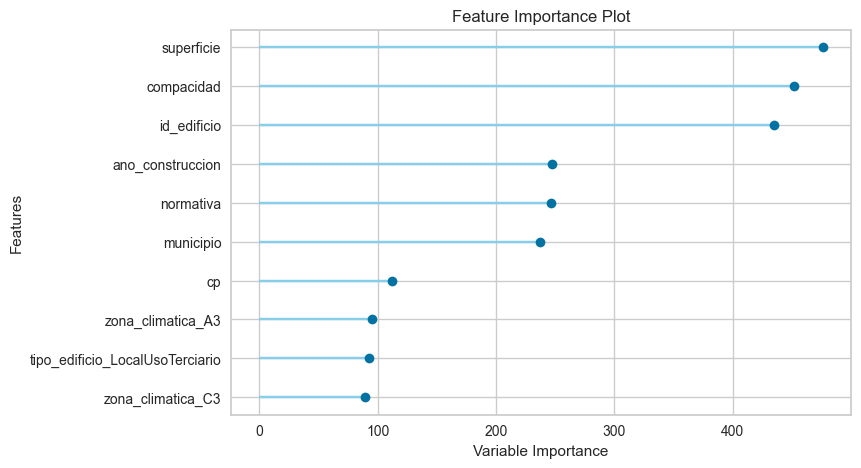

In [27]:
pc_reg.plot_model(model_lgbm, plot='feature')

### 3.2 Regresión consumos

In [8]:
pc_reg.setup(data=regresion_consumos, target='consumo_global', session_id=123)

,Description,Value
0,Session id,123
1,Target,consumo_global
2,Target type,Regression
3,Original data shape,"(1045614, 17)"
4,Transformed data shape,"(1045614, 34)"
5,Transformed train set shape,"(731929, 34)"
6,Transformed test set shape,"(313685, 34)"
7,Numeric features,10
8,Categorical features,6
9,Rows with missing values,37.1%


No vamos a meter rf ni et en esta comparación, ya que al tratarse de un dataset tan grande el pc va a sufrir. Los compararemos más delante con una muestra para poder tener una idea de cuales serán los mejores modelos.

In [9]:
best = pc_reg.compare_models(include = ['ridge','lightgbm', 'xgboost'], sort = 'R2')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
xgboost,Extreme Gradient Boosting,28.8093,1408.2250,37.5261,0.4961,0.3702,0.3273,2.9780
lightgbm,Light Gradient Boosting Machine,29.3758,1452.3442,38.1094,0.4803,0.3771,0.3376,2.7240
ridge,Ridge Regression,36.3068,2046.8943,45.2424,0.2676,0.4462,0.4218,2.0460


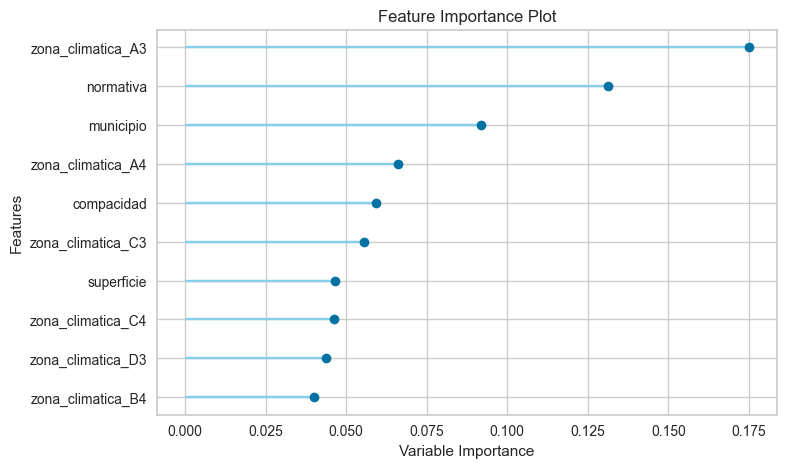

In [10]:
pc_reg.plot_model(best, plot='feature')

In [16]:
#Vamos con el rf y el et

df_sample = regresion_consumos.sample(frac=0.05, random_state=123)
pc_reg.setup(data=df_sample, target='consumo_global', transform_target=True, verbose=False)

In [10]:
best_trees = pc_reg.compare_models(include =['rf','et'], sort = 'R2')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3826,0.2890,0.5375,0.7153,0.2034,2.2620,2.1690
et,Extra Trees Regressor,0.3899,0.3008,0.5484,0.7036,0.2076,2.2613,1.3910


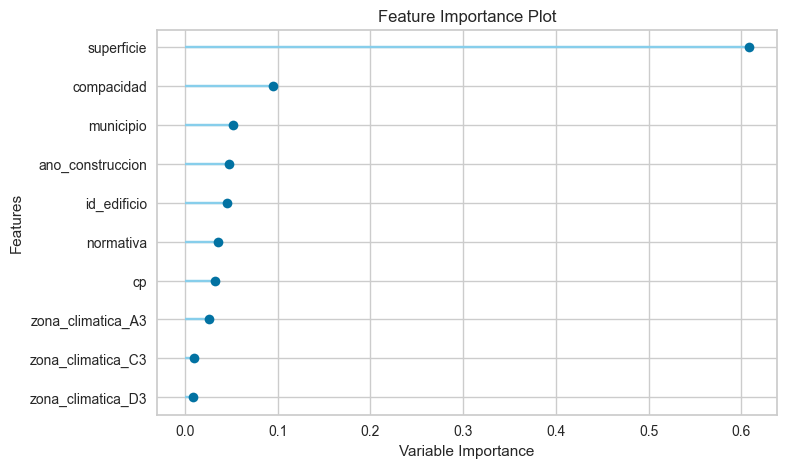

In [11]:
pc_reg.plot_model(best_trees,plot='feature')

### 3.3 Clasificaciones emisiones

In [44]:
features_clasif = [
    'provincia', 'zona_climatica', 'ano_construccion', 
    'normativa', 'tipo_edificio', 'superficie', 'compacidad'
]

In [46]:
s = pc_class.setup(
    data=clasificacion_emisiones[features_clasif + ['clase_emisiones']].sample(n=100000, random_state=123),
    target='clase_emisiones',
    session_id=123,
    # Forzamos a que no intente cosas raras con las categorías
    max_encoding_ohe=10, 
    # Si quieres que vaya volando, desactiva el fix_imbalance un momento para probar
    fix_imbalance=False 
)

,Description,Value
0,Session id,123
1,Target,clase_emisiones
2,Target type,Multiclass
3,Target mapping,"A: 0, B: 1, C: 2, D: 3, E: 4, F: 5, G: 6"
4,Original data shape,"(100000, 8)"
5,Transformed data shape,"(100000, 12)"
6,Transformed train set shape,"(70000, 12)"
7,Transformed test set shape,"(30000, 12)"
8,Numeric features,3
9,Categorical features,4


In [47]:
best = pc_class.compare_models(['catboost', 'lightgbm', 'xgboost'], sort='AUC')

In [49]:
resultados = pc_class.pull()
resultados

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.6179,0.8089,0.6179,0.5737,0.5766,0.3359,0.3490,8.144
lightgbm,Light Gradient Boosting Machine,0.6179,0.8080,0.6179,0.5717,0.5741,0.3322,0.3466,1.373
xgboost,Extreme Gradient Boosting,0.6155,0.8052,0.6155,0.5704,0.5740,0.3314,0.3443,0.970


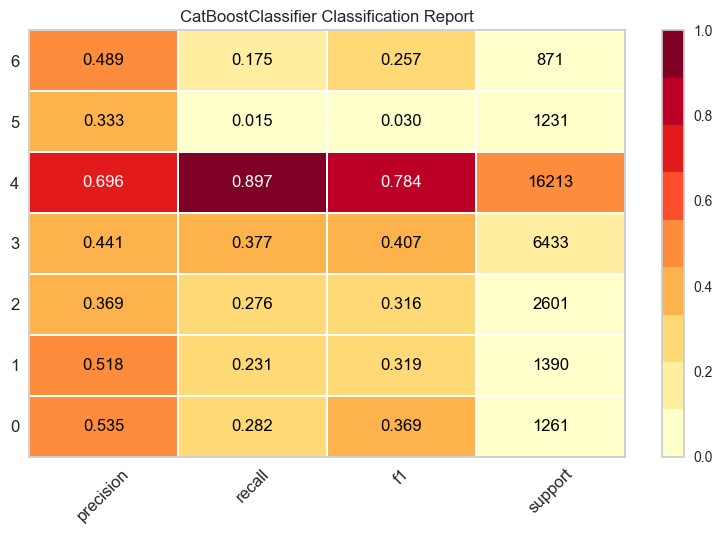

In [51]:
pc_class.plot_model(best, plot='class_report')

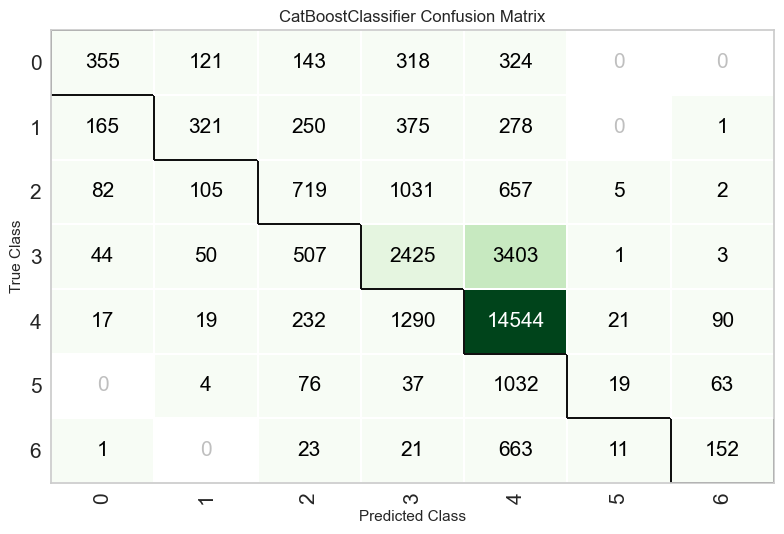

In [52]:
pc_class.plot_model(best, plot='confusion_matrix')

De momento, no voy a realizar la clasificación de consumos, ya que arrojará resultados similares. Creo que trabajaremos en una regresion para calcular los consumos, y en una clasificación de emisiones. Por lo que hemos visto aquí, creo que los datos tienen la calidad suficiente para que nos pongamos manos a la obra con la depuración final y el modelado.